# SMM Estimation
Structural estimation of `FullLaborModelClass` via Simulated Method of Moments.

**Workflow**
1. Initialise model and estimator  
2. Set starting values `theta0`  
3. Load data moments  
4. Verify moment function at `theta0`  
5. Run estimation (Nelder-Mead)  
6. Plot simulated vs empirical hazards  
7. Inspect parameter estimates

## 1. Setup

In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DynLaborSickModel import FullLaborModelClass
from Estimation import SMMEstimator, make_data_moments, moment_fit_table, PARAM_SPEC

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Initialise estimator

In [ ]:

est = SMMEstimator(
    FullLaborModelClass,
    calibrated = {
        'beta':    0.98,
        'tau':     0.30,
        'b_wel':   0.40,
        'Ubar':    24,
        'alpha':   0.10,   # calibrated from Mincer wage regression
        'delta_k': 0.05,   # calibrated depreciation rate
    },
)

pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])


## 3. Starting values
Set `theta0` to the default model parameter values.  
Adjust individual entries here before running estimation.

In [ ]:

_m = FullLaborModelClass()
_m.setup()
_p = _m.par

theta0 = np.array([
    _p.psi,            # job-finding scale
    _p.gamma,          # search cost curvature
    _p.iota,           # work disutility curvature
    _p.chi,            # participation cost coefficient
    _p.rho_h,          # health AR(1) persistence
    _p.sigma_h,        # health shock std dev
    _p.delta_h_S,      # health recovery drift on sick leave
    _p.delta0_doc,     # medical gate intercept
    _p.delta1_doc,     # medical gate slope (health)
    _p.b_sick_low,     # intermediate benefit post-reassessment
    _p.delta0_low,     # P(reduced benefit | h) intercept
    _p.delta1_low,     # P(reduced benefit | h) slope
    _p.delta0_out,     # P(kicked out | h) intercept
    _p.delta1_out,     # P(kicked out | h) slope
    _p.lambda_grid[0], # search cost scale type 0
    _p.lambda_grid[1], # search cost scale type 1
    _p.nu_grid[0],     # work disutility scale type 0
    _p.nu_grid[1],     # work disutility scale type 1
    _p.type_shares[1], # population share of type 1
    _p.h_init_mu[1],   # initial health z-shift type 1
])

# Print starting values alongside bounds
spec = pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])
spec.insert(1, 'theta0', theta0)
spec


## 4. Data moments
Load empirical hazard rates.  Add more moment DataFrames here as they become available —
anything left `None` is automatically excluded from the objective.

In [11]:

# ── S→E hazard (last 24 monthly observations) ──────────────────────────────
_hz_raw = pd.read_csv('hazard_monthly.csv', header=None)[0].values
_wt_raw = pd.read_csv('weight_monthly.csv', header=None)[0].values

hz_se_vals = _hz_raw[-24:]
wt_se_vals = _wt_raw[-24:]
durations  = np.arange(1, 25)

hz_se_data = pd.DataFrame({'duration': durations, 'hazard': hz_se_vals})

# ── Build data moments (add more DataFrames below when ready) ───────────────
data_moments = make_data_moments(
    hz_se_df    = hz_se_data,
    # hz_ue_df  = ...,   # U→E hazard
    # hz_us_df  = ...,   # U→S hazard
    # hz_su_df  = ...,   # S→U hazard
    # avg_s_dur = ...,   # mean sick-leave duration
    # share_S   = ...,   # share on sick leave
)

print(f'{len(data_moments)} moments loaded:')
for k, v in sorted(data_moments.items()):
    print(f'  {k:<25s} {v:.4f}')

# ── Diagonal weighting matrix from precision weights (one weight per duration)
_w = wt_se_vals / wt_se_vals.sum() * len(wt_se_vals)   # normalise to n
W_se = np.diag(_w)
print(f'\nWeighting matrix: {W_se.shape}')


24 moments loaded:
  hz_se_d01                 0.2948
  hz_se_d02                 0.2568
  hz_se_d03                 0.2562
  hz_se_d04                 0.2504
  hz_se_d05                 0.2462
  hz_se_d06                 0.2630
  hz_se_d07                 0.2914
  hz_se_d08                 0.2234
  hz_se_d09                 0.2323
  hz_se_d10                 0.2111
  hz_se_d11                 0.2094
  hz_se_d12                 0.1871
  hz_se_d13                 0.1862
  hz_se_d14                 0.1694
  hz_se_d15                 0.1610
  hz_se_d16                 0.1561
  hz_se_d17                 0.1702
  hz_se_d18                 0.1607
  hz_se_d19                 0.1652
  hz_se_d20                 0.1664
  hz_se_d21                 0.1340
  hz_se_d22                 0.1280
  hz_se_d23                 0.1426
  hz_se_d24                 0.1283

Weighting matrix: (24, 24)


## 5. Verify moment function at starting values
Runs the model once at `theta0` to confirm everything works before estimation.

In [12]:
m0 = est.compute_moments(theta0)

fit0 = moment_fit_table(m0, data_moments)
print(f'Q at theta0 = {est.objective(theta0, data_moments, W_se):.6f}\n')
display(fit0)

Q at theta0 = 0.084251



,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d01,0.294754,0.657877,0.363124,123.195554
hz_se_d02,0.256777,0.215641,-0.041136,-16.020039
hz_se_d03,0.256217,0.186778,-0.069439,-27.101759
hz_se_d04,0.250364,0.185197,-0.065167,-26.028899
hz_se_d05,0.246224,0.244893,-0.001330,-0.540342
hz_se_d06,0.263007,0.379433,0.116426,44.267250
hz_se_d07,0.291352,0.281351,-0.010001,-3.432531
hz_se_d08,0.223415,0.076742,-0.146673,-65.650430
hz_se_d09,0.232273,0.094247,-0.138026,-59.424129


## 6. Plot hazards at starting values

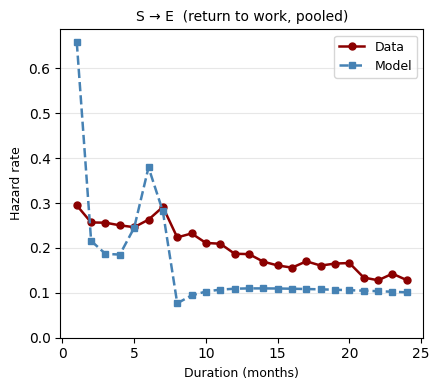

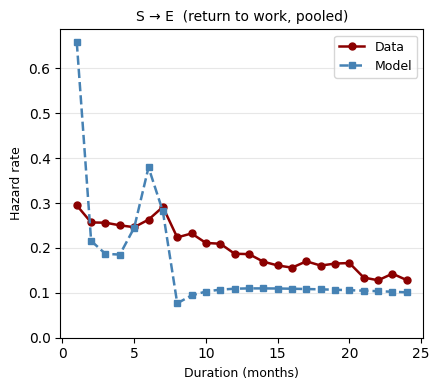

In [13]:
est.plot_fit(theta0, data_moments)

## 7. Run estimation
Nelder-Mead from `theta0`. If it converges to implausible values, try adjusting `theta0`.

In [14]:

result = est.estimate(
    data_moments,
    W              = W_se,
    theta0         = theta0,
    nm_maxiter     = 5000,
    progress_every = 5,
)
print(result['table'])


Nelder-Mead  (18 parameters)
  eval     5  |  best Q = 0.082293
  eval    10  |  best Q = 0.082293
  eval    15  |  best Q = 0.081192
  eval    20  |  best Q = 0.042877
  iter    21 evals  |  best Q = 0.034043
  iter    22 evals  |  best Q = 0.034043
  iter    23 evals  |  best Q = 0.034043
  iter    24 evals  |  best Q = 0.034043
  eval    25  |  best Q = 0.034043
  iter    25 evals  |  best Q = 0.034043
  iter    26 evals  |  best Q = 0.034043
  iter    27 evals  |  best Q = 0.034043
  iter    28 evals  |  best Q = 0.034043
  iter    29 evals  |  best Q = 0.034043
  eval    30  |  best Q = 0.034043
  iter    30 evals  |  best Q = 0.034043
  iter    31 evals  |  best Q = 0.034043
  iter    32 evals  |  best Q = 0.034043
  iter    33 evals  |  best Q = 0.034043
  iter    34 evals  |  best Q = 0.034043
  eval    35  |  best Q = 0.034043
  iter    35 evals  |  best Q = 0.034043
  iter    36 evals  |  best Q = 0.034043
  iter    37 evals  |  best Q = 0.034043
  iter    38 evals  |  best Q

## 8. Simulated vs empirical hazards at estimates

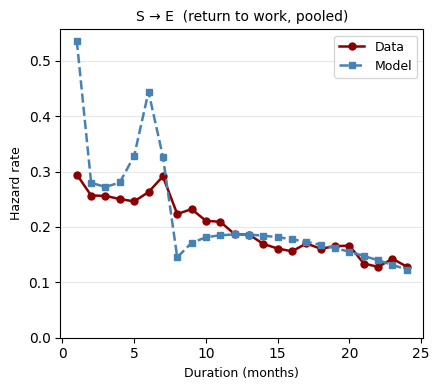

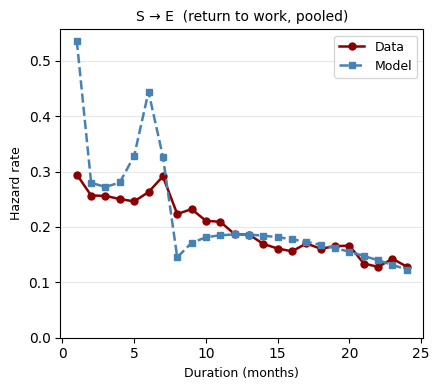

In [23]:
est.plot_fit(result['theta'], data_moments)  

## 9. Moment fit table

In [16]:
fit = moment_fit_table(est.compute_moments(result['theta']), data_moments)
display(fit)

,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d01,0.294754,0.536255,0.241501,81.933219
hz_se_d02,0.256777,0.279772,0.022995,8.955374
hz_se_d03,0.256217,0.272203,0.015986,6.239184
hz_se_d04,0.250364,0.280411,0.030047,12.001377
hz_se_d05,0.246224,0.328560,0.082336,33.439569
hz_se_d06,0.263007,0.444102,0.181095,68.855601
hz_se_d07,0.291352,0.327221,0.035869,12.311116
hz_se_d08,0.223415,0.145165,-0.078249,-35.024201
hz_se_d09,0.232273,0.171377,-0.060897,-26.217615


## 10. Re-estimation with optimal weighting matrix
Once you have a good first-round estimate, compute the efficient weighting matrix W* = Ω⁻¹  
and re-estimate. This up-weights precisely measured moments and gives correct standard errors.

In [17]:

# W_opt   = est.optimal_weight_matrix(result['theta'], data_moments, n_bootstrap=200)
# result2 = est.estimate(data_moments, W=W_opt, theta0=result['theta'])
# est.plot_fit(result2['theta'], data_moments)


## 11. Standard errors

In [18]:
# table = est.results_table(result['theta'], data_moments=data_moments,
#                            W=W_se, compute_se=True)
# display(table)